In [1]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, RR3short_gate, exchange10_gate, PulseSequence, DownPulse,  gen_MDFEup_seq, FreeEvolution
from sim_library.sequences2 import RR3short_gate as RR3short_gate2
from sim_library.sequences2 import exchange10_gate as exchange10_gate2
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21, fit_gaussian
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
### modified ex10 gate
rabi_freq = 2*pi*1e12
rabi_time = 2*pi/rabi_freq

detuning  = omega_eg/2
free_time = 2*pi/detuning

time_steps = 1

interf_cooler = PulseSequence()

pulse_1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = pi/2

MDFE_1 = gen_MDFEup_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, +detuning)), duration=7*free_time/8) 

interf_cooler.add_pulses([pulse_1,
                freevolve_1,
                MDFE_1,
                pulse_1,
                ])


In [48]:
N = 5000
Temp = 0.5e-6

cycles = 16

rabi_freq = 2*pi*5e10
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3short_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq()

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[20] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
# beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N)

moms_list, fracs_list, _ = simulate_alg_cooling_custom(basis=basis, sequence=RR3, n_atoms=N, temp=Temp, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3',
                                                    #    alternating=True,
                                                        # save_dir='data/algorithmic cooling',
                                                        )

In [3]:
path = Path("data/algorithmic cooling/2026-04-08_algcooling_f3_16cycles_15muK_5000atoms_5e+05Hz.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

In [49]:
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

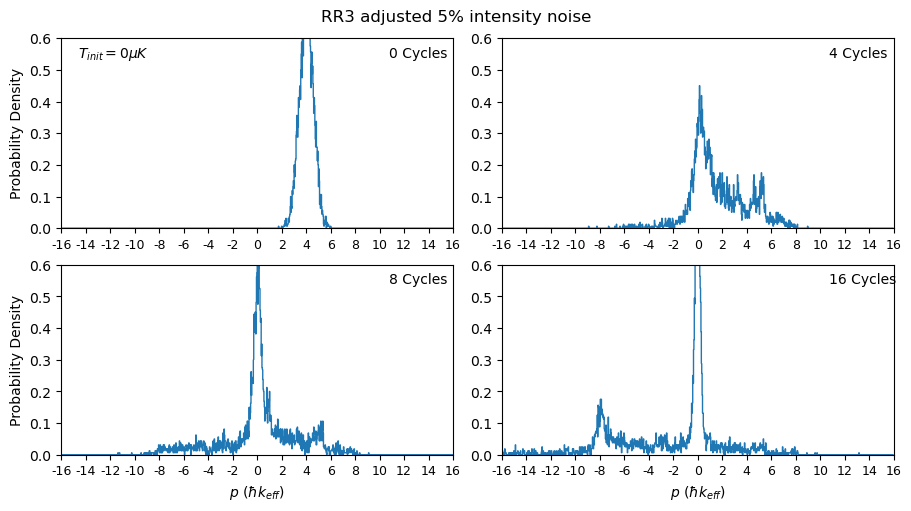

In [50]:


cycles_list = np.array([0,4,8,16])
index_list = np.array([0,8,16,32])
bins_list = np.full(4, 1000)
bins_list[0] = 1000

plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, title='RR3 adjusted 5% intensity noise', temp=Temp, show=False,
                      ylims=0.6,
                     #   save_dir="plots/histograms/RR2/2026-03-20_RR2_adjustedMDFE_0.05beam_f3_96cycles_15muK_6000atoms_1e6Hz.png"
                       )

Text(0.5, 0.01, 'Momentum ($\\hbar k_{eff}$)')

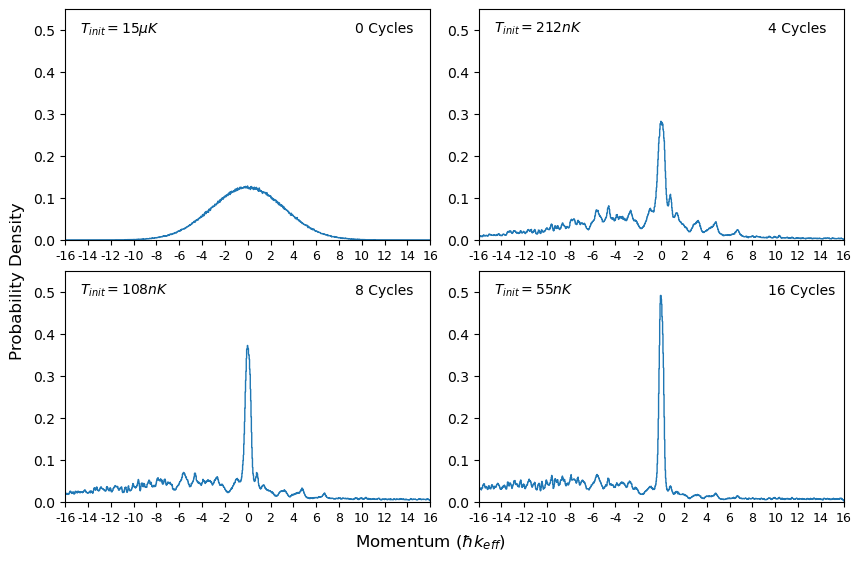

In [39]:
fig, axes = plt.subplots(2,2, figsize=(8.5, 5.5), layout= 'constrained')
axes = axes.flatten()

top = 0.55

for i in range(0,4):
        counts, _, _ = axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i]], bins = bins_list[i], histtype='step', density=True, range=(basis[0], basis[-1]))
        axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
        axes[i].set_xlim(basis[0],basis[-1])

yticks = np.arange(int(top*10)+1)*0.1

for i in range(0,4):
    axes[i].set_ylim(0,top)
    axes[i].set_yticks(yticks)
    axes[i].text((len(basis)*0.77)+basis[0],top*0.9,rf'{cycles_list[i]} Cycles')

axes[0].text((len(basis)*0.04)+basis[0],top*0.9,rf'$T_{{init}}={15:.0f}\mu K$')
axes[1].text((len(basis)*0.04)+basis[0],top*0.9,rf'$T_{{init}}={212:.0f}nK$')
axes[2].text((len(basis)*0.04)+basis[0],top*0.9,rf'$T_{{init}}={108:.0f}nK$')
axes[3].text((len(basis)*0.04)+basis[0],top*0.9,rf'$T_{{init}}={55.1:.0f}nK$')


fig.supylabel('Probability Density')
fig.supxlabel(r'Momentum ($\hbar k_{eff}$)')
# fig.show()

c:\Users\tr2g20\OneDrive - University of Southampton\Documents\Research\Code\Simulation\sim_library\plotting.py:295: RuntimeWarning: invalid value encountered in sqrt
  return (amp*hbar*k_eff/(np.sqrt(2*pi*m*kb*T)))*np.exp(-((hbar*k_eff)*(p-mu))**2/(2*kb*T*m))
c:\Users\tr2g20\OneDrive - University of Southampton\Documents\Research\Code\Simulation\sim_library\plotting.py:295: RuntimeWarning: overflow encountered in exp
  return (amp*hbar*k_eff/(np.sqrt(2*pi*m*kb*T)))*np.exp(-((hbar*k_eff)*(p-mu))**2/(2*kb*T*m))


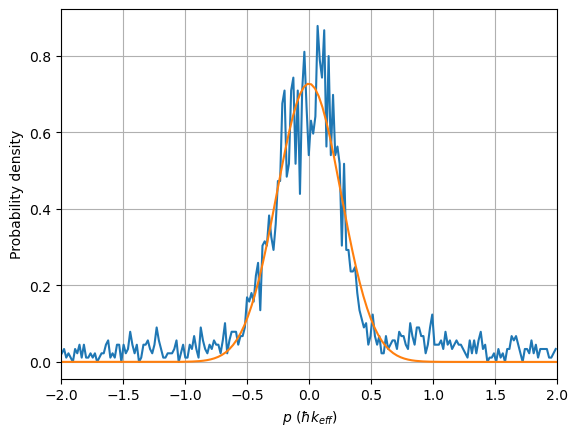

Efficiency: 47.1104%
Temperature: 0.0984283muK
Center: -0.0037729hbark


In [47]:
amp, T, shift, _ = fit_gaussian(moms_list[-1], fracs=fracs_list[-1], lowlim=-2, highlim=2, nbins=2000, plot=True)

print(f'Efficiency: {amp*100:.6g}%')
print(f'Temperature: {T*1e6:.6g}muK')
print(rf'Center: {shift:.6g}hbark')

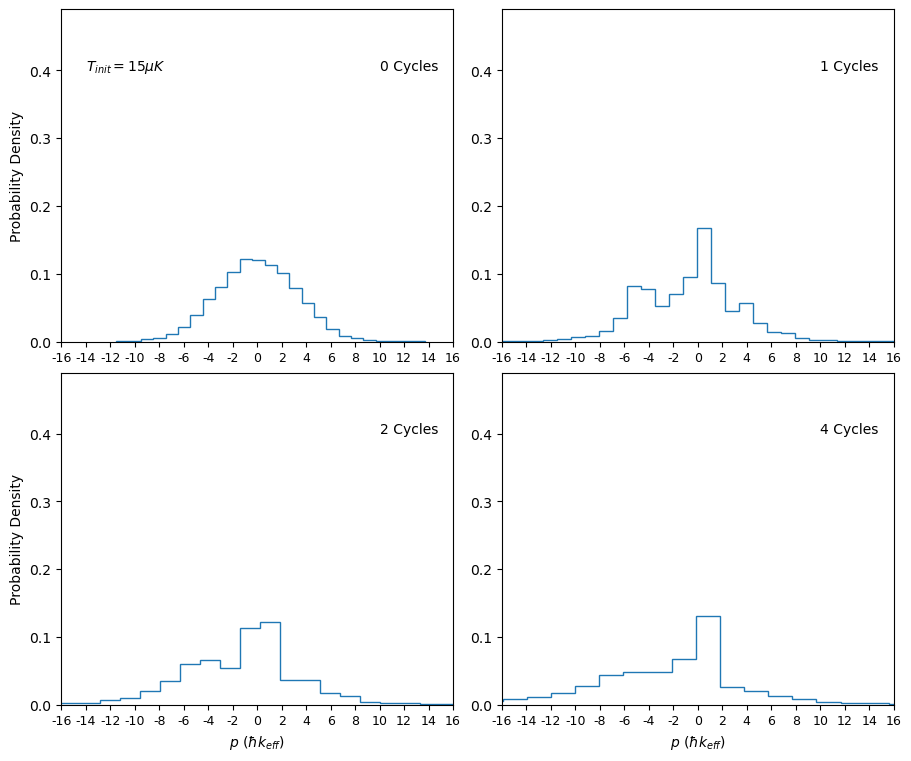

In [14]:
fig1, axes = plt.subplots(2,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 50

index_list = [0,1,3,7]


axes[0].hist(x= moms_list[0], bins = 25, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.49)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,4):
    axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i]], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.49)


axes[2].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[3].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()


ValueError: weights should have the same shape as x

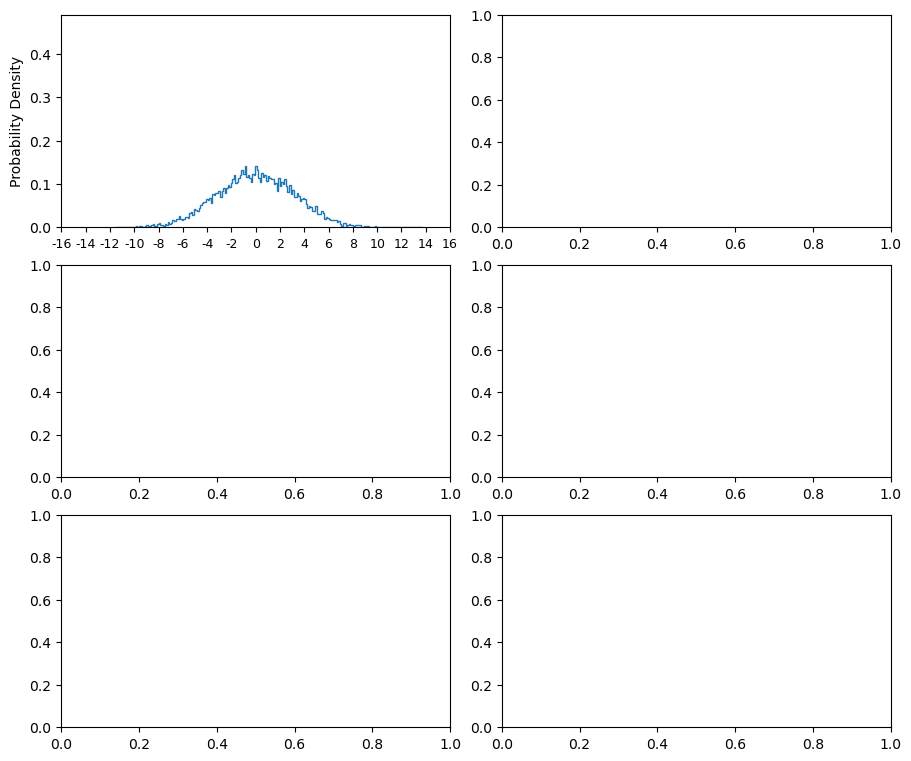

In [15]:

fig1, axes = plt.subplots(3,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 400

index_list = [0,1,3,5,7]

axes[0].hist(x= moms_list[0], bins = 200, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.49)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,6):
    axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i-1]], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.49)


axes[4].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[5].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')
axes[4].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')
axes[4].text(10,0.4,r'6 Cycles')
axes[5].text(10,0.4,r'8 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()
